In [1]:
import numpy as np
import os
import rasterio
from utils import get_project_dir
from eval_utils import compare_aligned_data
import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Aggregate predictions and calculate performance metrics

In [3]:
project_dir = get_project_dir()
resolution= 10
reference_maps = ['ETH', 'GLAD']
models = ['rf_4_channel']
pred_padding = 40
eval_metric = 'mae'

lidar_coarsened_dir = f'{project_dir}/data/int/lidar/lidar_by_site_32736_{resolution}m'
sites = sorted([x for x in os.listdir(lidar_coarsened_dir) if not x.startswith('.')])
results_by_site = {reference_maps[0]: {}, reference_maps[1]: {}}
results_by_site_plot = []
labels = []
preds = []
results = {reference_maps[0]: {}, reference_maps[1]: {}}
results_plot = []

# get results
for reference_map in reference_maps:
    reference_map_by_site_dir = f'{project_dir}/data/existing_reference_data/{reference_map.lower()}_maps_per_site_{resolution}m'

    for site in sites:
        with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
            site_labels = file.read().ravel()
            labels = np.append(labels, site_labels)

        with rasterio.open(f'{reference_map_by_site_dir}/{reference_map}_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
            site_preds = file.read().ravel()
            preds = np.append(preds, site_preds)

        results_by_site[reference_map][site] = compare_aligned_data(site_labels, site_preds)

    results_by_site_plot += [[results_by_site[reference_map][site][eval_metric] for site in sites]]
    
for model in models:
    model_output_dir = f'{project_dir}/data/model_output/rf_4_channel/'
    for site in sites:
        with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
            site_labels = file.read().ravel()
            labels = np.append(labels, site_labels)
        
        with rasterio.open(f'{model_output_dir}/{site}_{model}.tif') as file: # opens prediction tiff
            site_preds = file.read()[:,pred_padding:-pred_padding,pred_padding:-pred_padding].ravel()
            preds = np.append(preds, site_preds)

        results_by_site[reference_map][site] = compare_aligned_data(site_labels, site_preds)

    results_by_site_plot += [[results_by_site[reference_map][site][eval_metric] for site in sites]]

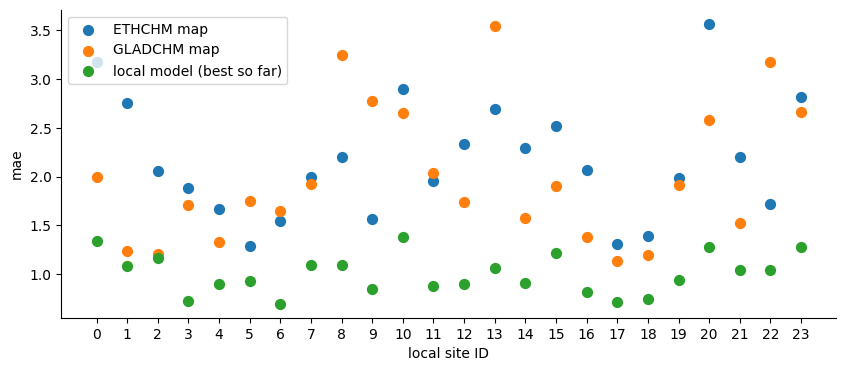

In [4]:
fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(sites))
width = 0.2
multiplier = 0

label_names = [x + 'CHM map' for x in reference_maps] + ['local model (best so far)']
for i in range(len(results_by_site_plot)):
    offset = width * i
    ax.scatter(x, results_by_site_plot[i], s=50, label=label_names[i])
    
sns.despine()
plt.legend()
ax.set_ylabel(eval_metric)
ax.set_xlabel('local site ID')
ax.set_xticks(np.arange(24));

# Visualize predictions


In [5]:
site = 'KaringaniSite01'
with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
    site_labels = file.read()[0]
        
with rasterio.open(f'{model_output_dir}/{site}_{model}.tif') as file: # opens prediction tiff
    site_preds = file.read()[0,pred_padding:-pred_padding,pred_padding:-pred_padding]

Text(0.5, 1.0, 'R2 score: 0.15')

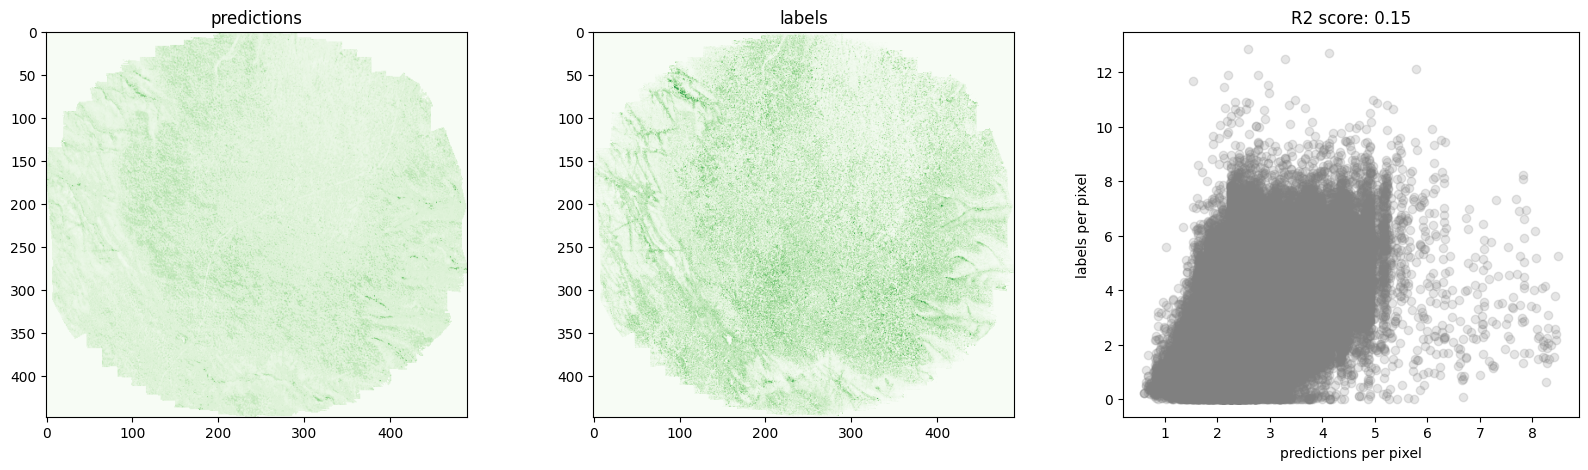

In [6]:
labels_print = site_labels.copy()
preds_print = site_preds.copy()
mask = labels_print < 0
preds_print[mask] = 0

fig, ax = plt.subplots(1,3,figsize=(20,5))
ax[0].imshow(preds_print, vmin=0, vmax=15, cmap='Greens')
ax[1].imshow(labels_print, vmin=0, vmax=15, cmap='Greens')
ax[2].scatter(preds_print[~mask], labels_print[~mask], color='grey', alpha=0.2)
ax[2].set_ylabel('labels per pixel')
ax[2].set_xlabel('predictions per pixel')
ax[0].set_title('predictions')
ax[1].set_title('labels')
ax[2].set_title(f'R2 score: {sklearn.metrics.r2_score(labels_print[~mask].ravel(), preds_print[~mask].ravel()) :.2f}')